In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

In [2]:
datos = pd.read_csv(filepath_or_buffer = "/Users/paola/Desktop/SA3/samsung.csv",sep=',',low_memory=False)

In [3]:
datos

,Date,Close,Volume
0,02/01/2008,10880,18047200
1,03/01/2008,10920,19346500
2,04/01/2008,10780,17997350
3,07/01/2008,10380,39787200
4,08/01/2008,10320,24783700
...,...,...,...
2845,24/06/2019,45500,6085066
2846,25/06/2019,45600,7076774
2847,26/06/2019,45700,9226097
2848,27/06/2019,46500,12603534


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Date    2850 non-null   str  
 1   Close   2850 non-null   int64
 2   Volume  2850 non-null   int64
dtypes: int64(2), str(1)
memory usage: 66.9 KB


In [5]:
datos.describe()

,Close,Volume
count,2850.000000,2.850000e+03
mean,26611.305263,1.610505e+07
std,11991.608543,8.661794e+06
min,8040.000000,0.000000e+00
25%,16300.000000,1.021426e+07
50%,25600.000000,1.359033e+07
75%,30850.000000,1.960970e+07
max,57220.000000,6.487345e+07


In [6]:
datos.isnull().sum()

Date      0
Close     0
Volume    0
dtype: int64

In [7]:
print("Datos duplicados:", datos.duplicated().sum())

Datos duplicados: 0


In [8]:
datos["Date"] = pd.to_datetime(
    datos["Date"],
    dayfirst=True
)

datos.head()

,Date,Close,Volume
0,2008-01-02,10880,18047200
1,2008-01-03,10920,19346500
2,2008-01-04,10780,17997350
3,2008-01-07,10380,39787200
4,2008-01-08,10320,24783700


In [9]:
print("Fecha inicial:", datos["Date"].min())
print("Fecha final:", datos["Date"].max())

Fecha inicial: 2008-01-02 00:00:00
Fecha final: 2019-06-28 00:00:00


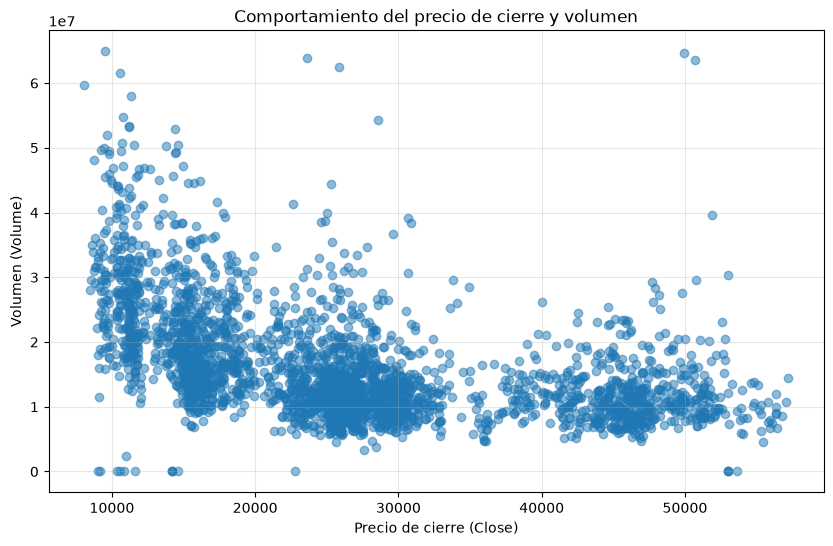

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    datos["Close"],
    datos["Volume"],
    alpha=0.5
)

plt.title("Comportamiento del precio de cierre y volumen")
plt.xlabel("Precio de cierre (Close)")
plt.ylabel("Volumen (Volume)")
plt.grid(alpha=0.3)

plt.show()

In [11]:
X = datos[["Close", "Volume"]]

X

,Close,Volume
0,10880,18047200
1,10920,19346500
2,10780,17997350
3,10380,39787200
4,10320,24783700
...,...,...
2845,45500,6085066
2846,45600,7076774
2847,45700,9226097
2848,46500,12603534


In [12]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled

array([[-1.31208968,  0.22425981],
       [-1.30875343,  0.37428969],
       [-1.32043031,  0.21850364],
       ...,
       [ 1.59211706, -0.79431101],
       [ 1.65884208, -0.40431911],
       [ 1.70054522, -0.36440155]], shape=(2850, 2))

In [13]:
inercias = []

valores_k = range(2, 11)

for k in valores_k:
    modelo_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    modelo_k.fit(X_scaled)
    inercias.append(modelo_k.inertia_)

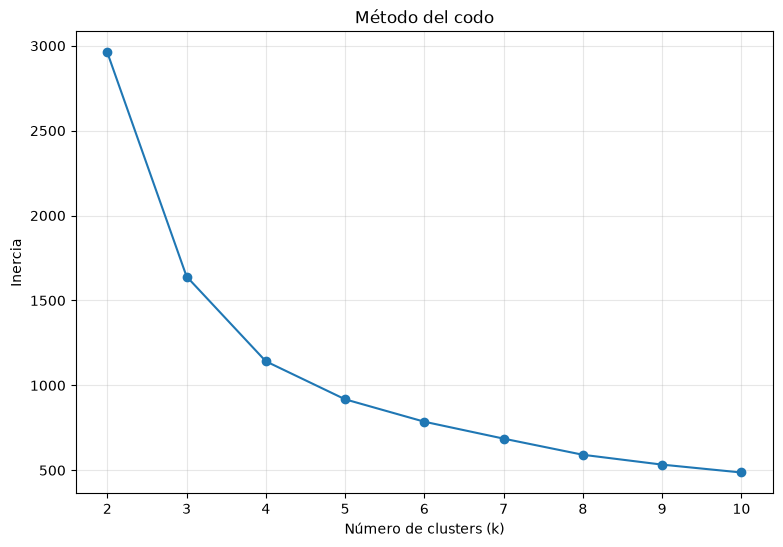

In [14]:
plt.figure(figsize=(9, 6))

plt.plot(
    valores_k,
    inercias,
    marker="o"
)

plt.title("Método del codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia")
plt.xticks(valores_k)
plt.grid(alpha=0.3)

plt.show()

In [15]:
silhouettes = []

for k in valores_k:
    modelo_k = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    etiquetas = modelo_k.fit_predict(X_scaled)
    
    score = silhouette_score(
        X_scaled,
        etiquetas
    )
    
    silhouettes.append(score)

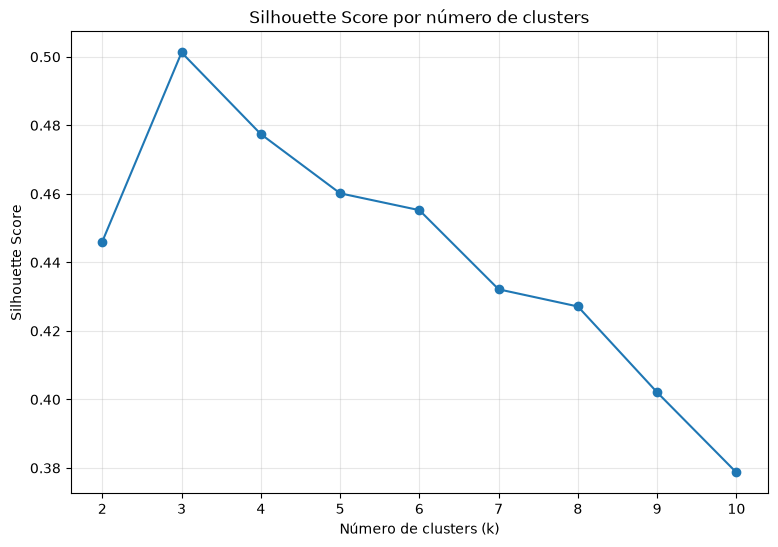

In [16]:
plt.figure(figsize=(9, 6))

plt.plot(
    valores_k,
    silhouettes,
    marker="o"
)

plt.title("Silhouette Score por número de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(valores_k)
plt.grid(alpha=0.3)

plt.show()

In [17]:
resultados_k = pd.DataFrame({
    "k": list(valores_k),
    "Inercia": inercias,
    "Silhouette Score": silhouettes
})

resultados_k

,k,Inercia,Silhouette Score
0,2,2960.349744,0.446086
1,3,1641.121715,0.501259
2,4,1141.748556,0.477436
3,5,917.924814,0.460161
4,6,785.907043,0.455241
5,7,686.337767,0.432140
6,8,591.292378,0.427130
7,9,533.257121,0.402068
8,10,486.915365,0.378677


In [18]:
mejor_indice = np.argmax(silhouettes)

mejor_k = list(valores_k)[mejor_indice]
mejor_silhouette = silhouettes[mejor_indice]

print("Mejor número de clusters:", mejor_k)
print("Mejor Silhouette Score:", mejor_silhouette)

Mejor número de clusters: 3
Mejor Silhouette Score: 0.5012589684919375


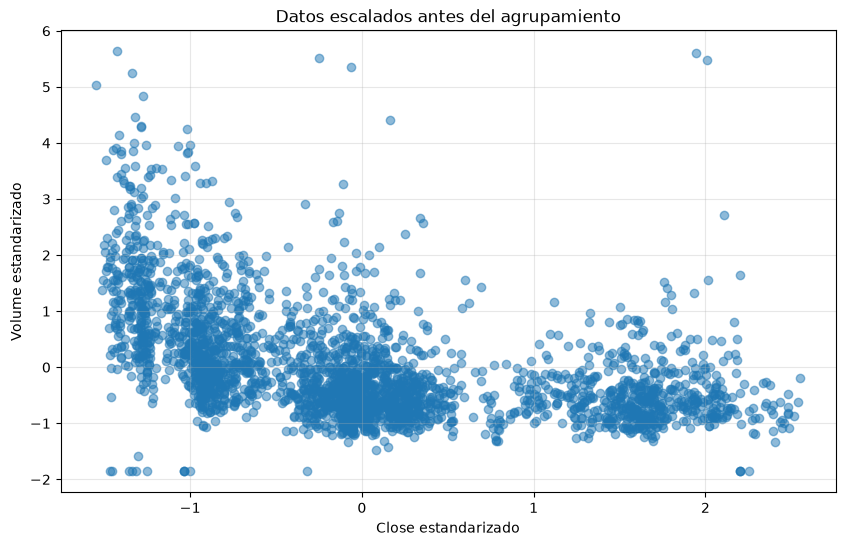

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    alpha=0.5
)

plt.title("Datos escalados antes del agrupamiento")
plt.xlabel("Close estandarizado")
plt.ylabel("Volume estandarizado")
plt.grid(alpha=0.3)

plt.show()

In [20]:
modelo_kmeans = KMeans(
    n_clusters=mejor_k,
    random_state=42,
    n_init=10
)

clusters = modelo_kmeans.fit_predict(X_scaled)

clusters

array([0, 2, 0, ..., 1, 1, 1], shape=(2850,), dtype=int32)

In [21]:
datos["Cluster"] = clusters

datos.head()

,Date,Close,Volume,Cluster
0,2008-01-02,10880,18047200,0
1,2008-01-03,10920,19346500,2
2,2008-01-04,10780,17997350,0
3,2008-01-07,10380,39787200,2
4,2008-01-08,10320,24783700,2


In [22]:
datos["Cluster"].value_counts().sort_index()

Cluster
0    1597
1     622
2     631
Name: count, dtype: int64

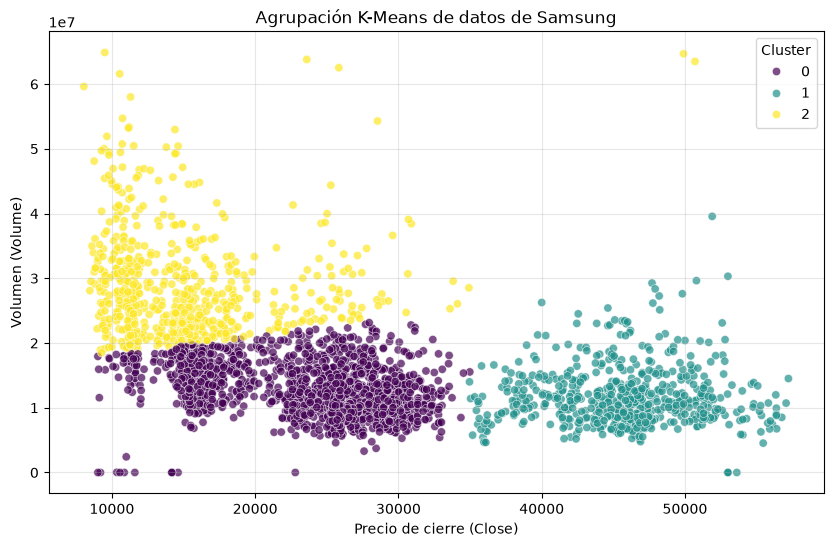

In [23]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=datos,
    x="Close",
    y="Volume",
    hue="Cluster",
    palette="viridis",
    alpha=0.7
)

plt.title("Agrupación K-Means de datos de Samsung")
plt.xlabel("Precio de cierre (Close)")
plt.ylabel("Volumen (Volume)")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)

plt.show()

In [24]:
modelo_kmeans.cluster_centers_

array([[-0.24360041, -0.38313089],
       [ 1.60323879, -0.5144436 ],
       [-0.96498584,  1.47972552]])

In [25]:
centroides = scaler.inverse_transform(
    modelo_kmeans.cluster_centers_
)

centroides_df = pd.DataFrame(
    centroides,
    columns=["Close", "Volume"]
)

centroides_df

,Close,Volume
0,23690.657071,1.278703e+07
1,45833.344051,1.164983e+07
2,15041.603175,2.891988e+07


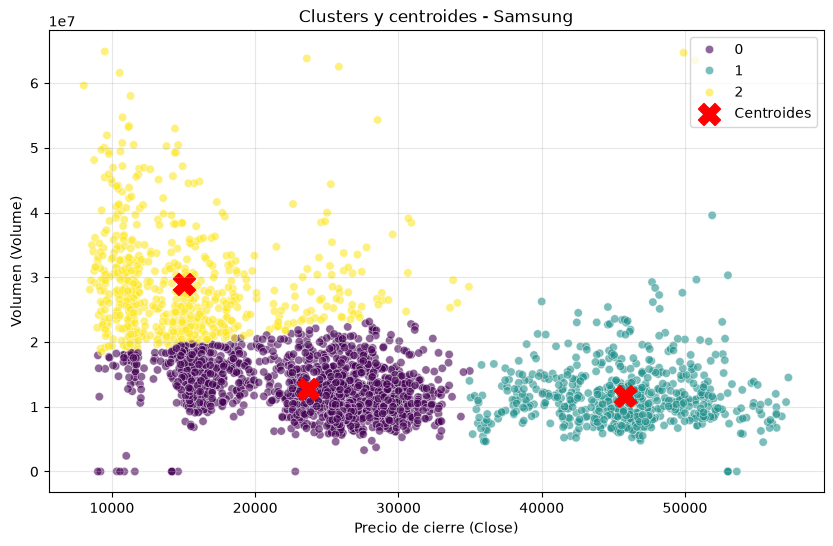

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=datos,
    x="Close",
    y="Volume",
    hue="Cluster",
    palette="viridis",
    alpha=0.6
)

plt.scatter(
    centroides_df["Close"],
    centroides_df["Volume"],
    marker="X",
    s=250,
    c="red",
    label="Centroides"
)

plt.title("Clusters y centroides - Samsung")
plt.xlabel("Precio de cierre (Close)")
plt.ylabel("Volumen (Volume)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [27]:
resumen_clusters = datos.groupby("Cluster")[["Close", "Volume"]].agg(
    ["count", "mean", "min", "max"]
)

resumen_clusters

Close                             Volume                          \
        count          mean    min    max  count          mean       min   
Cluster                                                                    
0        1597  23695.510332   9020  34980   1597  1.278258e+07         0   
1         622  45833.344051  34960  57220    622  1.164983e+07         0   
2         631  15043.026941   8040  50700    631  2.890558e+07  18496050   

                   
              max  
Cluster            
0        23142150  
1        39565391  
2        64873450

In [28]:
promedios_clusters = datos.groupby("Cluster")[["Close", "Volume"]].mean()

promedios_clusters

,Close,Volume
Cluster,,
0,23695.510332,1.278258e+07
1,45833.344051,1.164983e+07
2,15043.026941,2.890558e+07


In [30]:
resultados_optimizacion = []

for init in ["k-means++", "random"]:
    for n_init in [10, 20, 30]:
        for max_iter in [100, 300, 500]:
            
            modelo_temp = KMeans(
                n_clusters=mejor_k,
                init=init,
                n_init=n_init,
                max_iter=max_iter,
                random_state=42
            )
            
            etiquetas_temp = modelo_temp.fit_predict(X_scaled)
            
            silhouette = silhouette_score(
                X_scaled,
                etiquetas_temp
            )
            
            resultados_optimizacion.append({
                "init": init,
                "n_init": n_init,
                "max_iter": max_iter,
                "Silhouette Score": silhouette,
                "Inercia": modelo_temp.inertia_
            })

In [31]:
resultados_optimizacion_df = pd.DataFrame(
    resultados_optimizacion
)

resultados_optimizacion_df

,init,n_init,max_iter,Silhouette Score,Inercia
0,k-means++,10,100,0.501259,1641.121715
1,k-means++,10,300,0.501259,1641.121715
2,k-means++,10,500,0.501259,1641.121715
3,k-means++,20,100,0.501259,1641.121715
4,k-means++,20,300,0.501259,1641.121715
5,k-means++,20,500,0.501259,1641.121715
6,k-means++,30,100,0.501259,1641.121715
7,k-means++,30,300,0.501259,1641.121715
8,k-means++,30,500,0.501259,1641.121715
9,random,10,100,0.501259,1641.121715


In [32]:
mejor_configuracion = resultados_optimizacion_df.loc[
    resultados_optimizacion_df["Silhouette Score"].idxmax()
]

mejor_configuracion

init                  k-means++
n_init                       10
max_iter                    100
Silhouette Score       0.501259
Inercia             1641.121715
Name: 0, dtype: object

In [33]:
print("Mejor configuración:")
print("init:", mejor_configuracion["init"])
print("n_init:", mejor_configuracion["n_init"])
print("max_iter:", mejor_configuracion["max_iter"])
print("Silhouette Score:", mejor_configuracion["Silhouette Score"])
print("Inercia:", mejor_configuracion["Inercia"])

Mejor configuración:
init: k-means++
n_init: 10
max_iter: 100
Silhouette Score: 0.5012589684919375
Inercia: 1641.1217154102594


In [34]:
modelo_optimizado = KMeans(
    n_clusters=mejor_k,
    init=mejor_configuracion["init"],
    n_init=int(mejor_configuracion["n_init"]),
    max_iter=int(mejor_configuracion["max_iter"]),
    random_state=42
)

clusters_optimizados = modelo_optimizado.fit_predict(
    X_scaled
)

In [35]:
silhouette_optimizado = silhouette_score(
    X_scaled,
    clusters_optimizados
)

print(
    "Silhouette modelo inicial:",
    mejor_silhouette
)

print(
    "Silhouette modelo optimizado:",
    silhouette_optimizado
)

print(
    "Inercia modelo optimizado:",
    modelo_optimizado.inertia_
)

Silhouette modelo inicial: 0.5012589684919375
Silhouette modelo optimizado: 0.5012589684919375
Inercia modelo optimizado: 1641.1217154102594


In [36]:
modelo_final = {
    "scaler": scaler,
    "modelo": modelo_optimizado
}

joblib.dump(
    modelo_final,
    "modelo_agrupacion_samsung.pkl"
)

print("Modelo guardado correctamente")

Modelo guardado correctamente


In [37]:
modelo_cargado = joblib.load(
    "modelo_agrupacion_samsung.pkl"
)

scaler_cargado = modelo_cargado["scaler"]
kmeans_cargado = modelo_cargado["modelo"]

X_cargado = scaler_cargado.transform(X)

clusters_prueba = kmeans_cargado.predict(
    X_cargado
)

print(clusters_prueba)

[0 2 0 ... 1 1 1]
